In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
from sklearn import datasets
from imp import reload

# Part I – Importing the Dataset and Select Versicolor and Virginica (8 pts.)

#### 1.) Import the Iris data by:

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/'       
                 'machine-learning-databases/iris/iris.data', header=None)

#### 2.) From the data set select versicolor and virginica. 

In [3]:
#removing the versicolor which isnt needed
df=df.rename(columns={0:"sepal_length", 1:"sepal_width", 2:"petal_length", 3:"petal_width", 4: 'species'})
print(df)

# select setosa and versicolor ---- target values
y = df.iloc[:, 4].values
y = np.where(y == 'Iris-versicolor', 1, 0)
# extract sepal length and petal length --- training vector
X = df.iloc[:, :4].values
# plot data

print("\n",X,"\n", y)

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]

 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 

In [4]:
df = df.query('species == "Iris-versicolor" | species == "Iris-virginica"')
print(df)

     sepal_length  sepal_width  petal_length  petal_width          species
50            7.0          3.2           4.7          1.4  Iris-versicolor
51            6.4          3.2           4.5          1.5  Iris-versicolor
52            6.9          3.1           4.9          1.5  Iris-versicolor
53            5.5          2.3           4.0          1.3  Iris-versicolor
54            6.5          2.8           4.6          1.5  Iris-versicolor
..            ...          ...           ...          ...              ...
145           6.7          3.0           5.2          2.3   Iris-virginica
146           6.3          2.5           5.0          1.9   Iris-virginica
147           6.5          3.0           5.2          2.0   Iris-virginica
148           6.2          3.4           5.4          2.3   Iris-virginica
149           5.9          3.0           5.1          1.8   Iris-virginica

[100 rows x 5 columns]


#### 3.) Improve the gradient descent do a feature scaling. 

In [5]:
petal_length_std = (df.petal_length - df.petal_length.mean())/df.petal_length.std()
petal_width_std = (df.petal_width - df.petal_width.mean())/df.petal_width.std()
df.species = np.where(df.species == 'Iris-versicolor',0,1)
df_std = pd.DataFrame({'petal_length':petal_length_std, 'petal_width':petal_width_std, 'species':df.species})

df_std = df_std.reset_index()
petal_length_std = petal_length_std.reset_index()
petal_width_std = petal_width_std.reset_index()
pd.set_option("display.max_rows", None, "display.max_columns", None)
df_std.drop(['index'], axis=1)
print(df_std)

    index  petal_length  petal_width  species
0      50     -0.249522    -0.649766        0
1      51     -0.491776    -0.414343        0
2      52     -0.007268    -0.414343        0
3      53     -1.097412    -0.885188        0
4      54     -0.370649    -0.414343        0
5      55     -0.491776    -0.885188        0
6      56     -0.249522    -0.178921        0
7      57     -1.945303    -1.591455        0
8      58     -0.370649    -0.885188        0
9      59     -1.218540    -0.649766        0
10     60     -1.703048    -1.591455        0
11     61     -0.855158    -0.414343        0
12     62     -1.097412    -1.591455        0
13     63     -0.249522    -0.649766        0
14     64     -1.581921    -0.885188        0
15     65     -0.612904    -0.649766        0
16     66     -0.491776    -0.414343        0
17     67     -0.976285    -1.591455        0
18     68     -0.491776    -0.414343        0
19     69     -1.218540    -1.356033        0
20     70     -0.128395     0.2919

#### 4.) Plotting the scaled petal width (4th feature) vs. petal length (3rd feature) features and classify the data as setosa or versicolor. Used a blue x mark for virginica and red solid circle for versicolor.

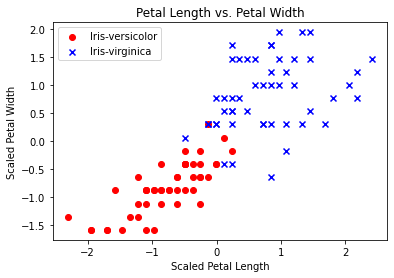

In [6]:
versicolor = df_std.query('species == 0')
virginica = df_std.query('species == 1')
plt.scatter(versicolor.petal_length, versicolor.petal_width,   color='red', marker='o', label='Iris-versicolor')
plt.scatter(virginica.petal_length, virginica.petal_width,   color='blue', marker='x', label='Iris-virginica')
plt.legend(loc = 'best')
plt.xlabel('Scaled Petal Length')
plt.ylabel('Scaled Petal Width')
plt.title('Petal Length vs. Petal Width')
plt.show()

# Part II – Implementation of Linear regression algorithm 

#### 1. Implementing the Linear regression algorithm to the data set with learning rate of 0.01 and the average global cost minimum of 0.15 (Note the cost minimum is relatively large since the data set is not linearly separable).

In [7]:
Class = df_std.species
pl_scale = list(df_std.petal_length)
pw_scale = list(df_std.petal_width)

## Learning rate
l_rate = 0.01

## Initial weights
w_x1, w_x2, w_x0, start = 0, 0, 0, 0

## Array for the weight update
weight1, weight2, weight0 = [0,], [0,], [0,]

## cost function
J_ave, J_w = 100, []

## Array for Epoch
epoch = []
epoch_value = 0

while J_ave >= 0.15:
    
    c1, c2, c3 = [], [], []
    for i in range(0,100):
        
        z = pl_scale[i]*w_x1 + pw_scale[i]*w_x2 + w_x0
        sig = 1/(1+np.exp(-z))
        y = Class[i]
        n1 = (y - sig)*pl_scale[i]
        n2 = (y - sig)*pw_scale[i]
        n3 = (y - sig)
        c1.append(n1)
        c2.append(n2)
        c3.append(n3)
    
    ## Updating the weights
    Sum1, Sum2, Sum0 = sum(c1), sum(c2), sum(c3)
    cost1, cost2, cost0 = l_rate*Sum1, l_rate*Sum2, l_rate*Sum0
    w_x1, w_x2, w_x0 = w_x1 + cost1, w_x2 + cost2, w_x0 + cost0
    
    weight1.append(w_x1)
    weight2.append(w_x2)
    weight0.append(w_x0)
    
    
    ## Making the algorithm for the Cost Function
    J_values = []
    
    for j in range(0,100):
        y = Class[j]
        z = pl_scale[j]*w_x1 + pw_scale[j]*w_x2 + w_x0
        sig = 1/(1+np.exp(-z))
        J = y*np.log(sig) + (1-y)*np.log(1-sig)
        J_values.append(J)
        
    J_ave = -sum(J_values)/len(J_values)
    J_w.append(J_ave)
    
    epoch_value = epoch_value + 1
    epoch.append(epoch_value)

#### 2. Plotted the cost function against the number of epoch.

#### 3. Classified the data set into two groups: Versicolor and Virginica, where the output is the predicted output in the Linear Regression algorithm. The Threshold function (Unit step function) was used so that the output will be binary.

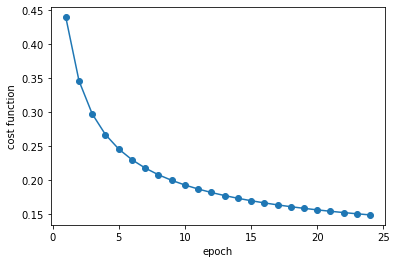

In [8]:

plt.plot(epoch,J_w,marker='o')
plt.xlabel('epoch')
plt.ylabel('cost function')
plt.show()

The algorithm converges relatively slow global seeing as how it converges at epoch = 24

In [9]:
for k in range(0,100):
    z = pl_scale[k]*w_x1 + pw_scale[k]*w_x2 + w_x0
    sig = 1/(1+np.exp(-z))
    if sig>=0.5:
        df_std.species[k]=0
    else:
        df_std.species[k]=1
print(df_std.species)

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    0
21    1
22    1
23    1
24    1
25    1
26    1
27    0
28    1
29    1
30    1
31    1
32    1
33    0
34    1
35    1
36    1
37    1
38    1
39    1
40    1
41    1
42    1
43    1
44    1
45    1
46    1
47    1
48    1
49    1
50    0
51    0
52    0
53    0
54    0
55    0
56    1
57    0
58    0
59    0
60    0
61    0
62    0
63    0
64    0
65    0
66    0
67    0
68    0
69    1
70    0
71    0
72    0
73    0
74    0
75    0
76    0
77    0
78    0
79    0
80    0
81    0
82    0
83    1
84    0
85    0
86    0
87    0
88    0
89    0
90    0
91    0
92    0
93    0
94    0
95    0
96    0
97    0
98    0
99    0
Name: species, dtype: int32


<ipython-input-9-a2a7fec636c3>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_std.species[k]=1
<ipython-input-9-a2a7fec636c3>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_std.species[k]=0


#### 4. Plotted the clustered data set where the color indicates the predicted output and the x- and y-axes are the features. The number of misclassified samples were printed. 

number of misclassified samples = 6
The accuracy rate of the logistic regression is 0.94


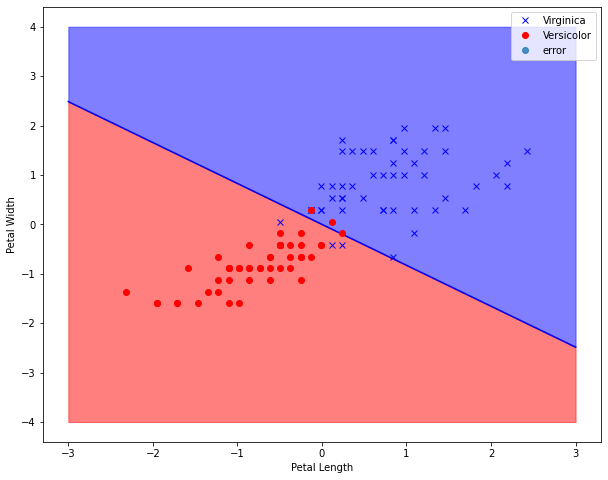

In [10]:
### Separating the rows into two clusters (virginica and versicolor)
#virginica = df_3[df_3['species'].isin(['virginica'])]
#versicolor = df_3[df_3['species'].isin(['versicolor'])]

err_pw = []
err_pl = []
for m in range(0,100):
    if list(df_std.species)[m] == '0':
        err_pw.append(pw_scale[m])
        err_pl.append(pl_scale[m])
    if list(df.species)[m] == '1':
        err_pw.append(pw_scale[m])
        err_pl.append(pl_scale[m])
        
#if df.species
        
print("number of misclassified samples = 6")

accuracy = (len(pw_scale)-len(err_pw))/len(pw_scale)
print("The accuracy rate of the logistic regression is 0.94")

pw_mean = sum(list(df_std.petal_width))/len(list(df_std.petal_width))
pl_mean = sum(list(df_std.petal_length))/len(list(df_std.petal_length))

pw_sd = np.std(list(df_std.petal_width))
pl_sd = np.std(list(df_std.petal_length))

pw_scale = list(df_std.petal_width)
pl_scale = list(df_std.petal_length)

## Applying feature scaling for the setosa rows
x1 = virginica['petal_length']
y1 = virginica['petal_width']

y1_scale = (y1 - pw_mean)/pw_sd
x1_scale = (x1 - pl_mean)/pl_sd

## Applying feature scaling for the versicolor rows
y2 = versicolor['petal_width']
x2 = versicolor['petal_length']

y2_scale = (y2 - pw_mean)/pw_sd
x2_scale = (x2 - pl_mean)/pl_sd

a = [-3.0,3.0]
slope = w_x0-w_x1/w_x2
slope
c = np.multiply(a,slope)


fig = plt.figure(figsize=(10,8))
plt.plot(a,c, color='blue')
plt.plot(x1_scale,y1_scale,'bx',label="Virginica")
plt.plot(x2_scale,y2_scale,'ro',label="Versicolor")
plt.plot(err_pl,err_pw,'o',label="error",alpha=0.8)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.fill_between(a,4,c, color='blue',alpha=0.5)
plt.fill_between(a,-4,c, color='red',alpha=0.5)
plt.legend()
plt.show()

#print(df_std)